In [7]:
from torch_snippets import *
from torchvision.datasets import MNIST
from torchvision import transforms
from torchvision import datasets, transforms
from torchvision.utils import make_grid

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = MNIST('./data', transform=transforms.ToTensor(), train=True, download=True) 
test_dataset= MNIST('./data', transform=transforms.ToTensor(), train=False, download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset,batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=train_dataset,batch_size=64, shuffle=True)

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable

class VAE(nn.Module):
    def __init__(self):
        super(VAE,self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 256) # 3136 neuronios vai ate 20
        self.fc21 = nn.Linear(256, 20) 
        self.fc22 = nn.Linear(256, 20) 

        self.fc3 = nn.Linear(20, 256)
        self.fc4 = nn.Linear(256, 64 * 7 * 7)
        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.deconv2 = nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1)

    def encode(self, x):# reduz a imagem por meio das camadas densas e rretorna dois vetores
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        mu = self.fc21(x)
        logvar = self.fc22(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):# sorteia um ponto z da distribuicao diferente, assim separando a parte aleatoria da parte aprendida
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = Variable(torch.randn(std.size()))
            return eps.mul(std).add_(mu)
        else:
            return mu

    def decode(self, z):# vai recontruir a imagem a partir do vetor z, quue foi calculado em reparameterize
        z = F.relu(self.fc3(z))
        z = F.relu(self.fc4(z))
        z = z.view(z.size(0), 64, 7, 7)# reformata de vetor pra imagem com 64 canais 7x7
        z = F.relu(self.deconv1(z))
        z = torch.sigmoid(self.deconv2(z))
        return z

    def forward(self, x):# faz o fluxo completo funcionar
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        z = self.decode(z)
        return z, mu, logvar

In [13]:
def train_batch(data, model, optimizer, loss_function):# treina a rede 
    model.train()

    optimizer.zero_grad()# zera o gradiente
    recon_batch, mean, log_var = model(data)
    loss, mse, kld = loss_function(recon_batch, data, mean, log_var)
    loss.backward()
    optimizer.step()
    return loss, mse, kld, log_var.mean(), mean.mean()


@torch.no_grad()# valida com dados que nao viu
def validate_batch(data, model, loss_function):
    model.eval()

    recon, mean, log_var = model(data)
    loss, mse, kld = loss_function(recon, data, mean, log_var)
    return loss, mse, kld, log_var.mean(), mean.mean()

In [14]:
def loss_function(recon_x,x,mean,log_var):
    RECON = F.mse_loss(recon_x,x,reduction='sum')# compara a imagem reconstruida apos os encoders com  a original
    KLD=-0.5 * torch.sum(1+log_var - mean.pow(2) - log_var.exp()) # mede a diferença entre as duas distribuições
    return RECON + KLD, RECON,KLD

EPOCH: 1.000  train_mean: 0.002  train_kld: 388.368  val_loss: 1891.058  val_log_var: -0.908  val_mean: -0.002  train_loss: 2686.073  train_log_var: -0.578  train_recon: 2297.705  val_kld: 602.381  val_recon: 1288.677  (45.28s - 407.48s remaining)


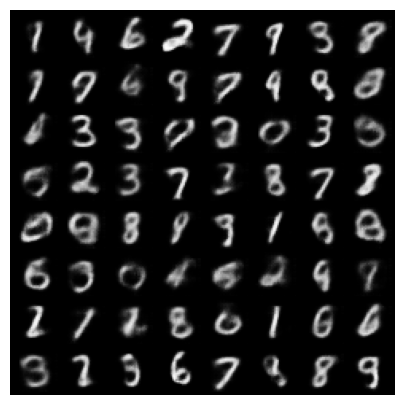

EPOCH: 2.000  train_mean: 0.001  train_kld: 638.264  val_loss: 1671.250  val_log_var: -1.016  val_mean: -0.008  train_loss: 2043.737  train_log_var: -0.990  train_recon: 1405.473  val_kld: 653.154  val_recon: 1018.095  (124.33s - 497.32s remaining)


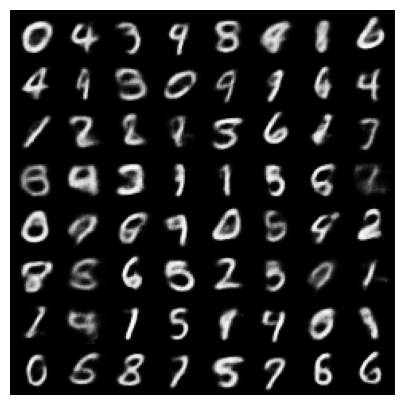

EPOCH: 3.000  train_mean: 0.001  train_kld: 687.807  val_loss: 1656.730  val_log_var: -1.128  val_mean: 0.012  train_loss: 1940.449  train_log_var: -1.072  train_recon: 1252.642  val_kld: 723.886  val_recon: 932.844  (171.93s - 401.16s remaining)


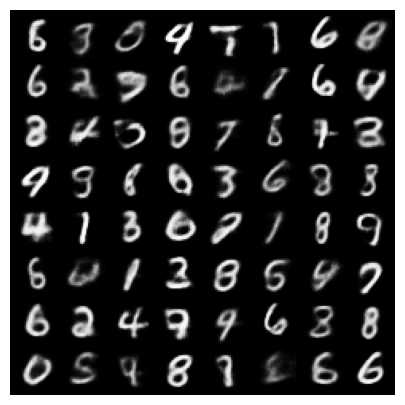

EPOCH: 4.000  train_mean: -0.000  train_kld: 708.792  val_loss: 1568.796  val_log_var: -1.084  val_mean: -0.002  train_loss: 1902.275  train_log_var: -1.107  train_recon: 1193.484  val_kld: 697.932  val_recon: 870.864  (229.40s - 344.10s remaining)


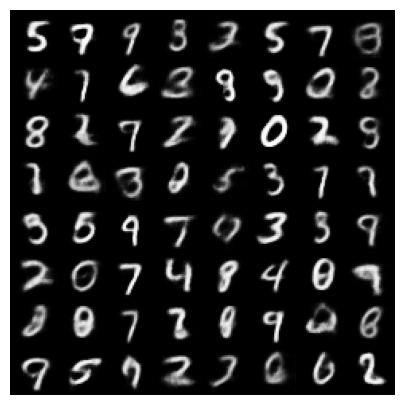

EPOCH: 5.000  train_mean: 0.000  train_kld: 716.957  val_loss: 1553.009  val_log_var: -1.116  val_mean: 0.005  train_loss: 1872.805  train_log_var: -1.120  train_recon: 1155.848  val_kld: 714.714  val_recon: 838.295  (297.73s - 297.73s remaining)


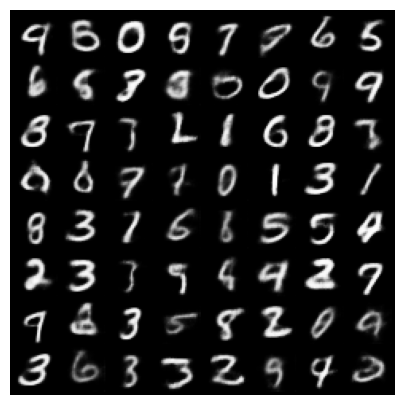

EPOCH: 6.000  train_mean: 0.001  train_kld: 725.251  val_loss: 1526.857  val_log_var: -1.118  val_mean: -0.004  train_loss: 1854.009  train_log_var: -1.133  train_recon: 1128.758  val_kld: 714.886  val_recon: 811.971  (403.26s - 268.84s remaining)


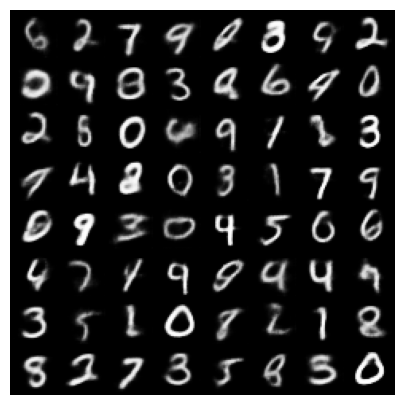

EPOCH: 7.000  train_mean: -0.000  train_kld: 731.696  val_loss: 1529.487  val_log_var: -1.137  val_mean: 0.014  train_loss: 1836.750  train_log_var: -1.144  train_recon: 1105.054  val_kld: 730.643  val_recon: 798.844  (447.75s - 191.89s remaining)


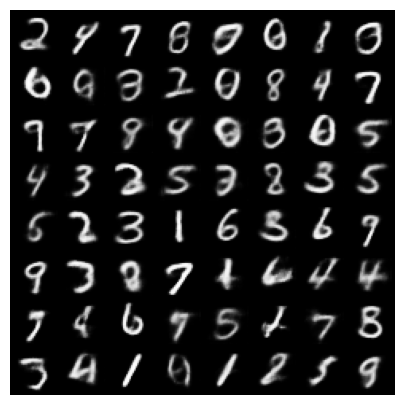

EPOCH: 8.000  train_mean: 0.000  train_kld: 738.749  val_loss: 1516.451  val_log_var: -1.156  val_mean: -0.002  train_loss: 1825.277  train_log_var: -1.155  train_recon: 1086.528  val_kld: 733.827  val_recon: 782.624  (489.32s - 122.33s remaining)


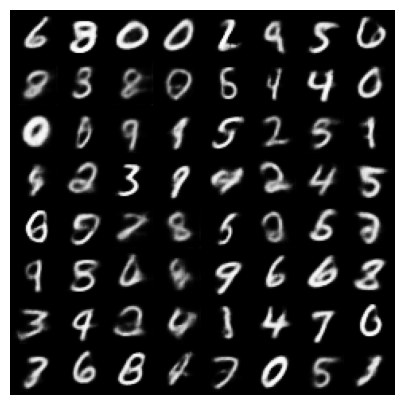

EPOCH: 9.000  train_mean: 0.000  train_kld: 742.294  val_loss: 1528.644  val_log_var: -1.194  val_mean: -0.001  train_loss: 1812.757  train_log_var: -1.161  train_recon: 1070.463  val_kld: 767.205  val_recon: 761.439  (544.04s - 60.45s remaining)


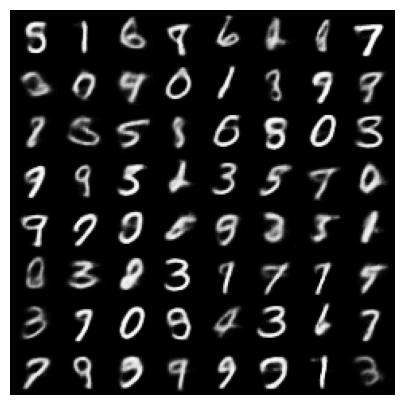

EPOCH: 10.000  train_mean: 0.000  train_kld: 746.856  val_loss: 1520.081  val_log_var: -1.168  val_mean: -0.004  train_loss: 1806.683  train_log_var: -1.168  train_recon: 1059.827  val_kld: 744.065  val_recon: 776.017  (630.96s - 0.00s remaining)


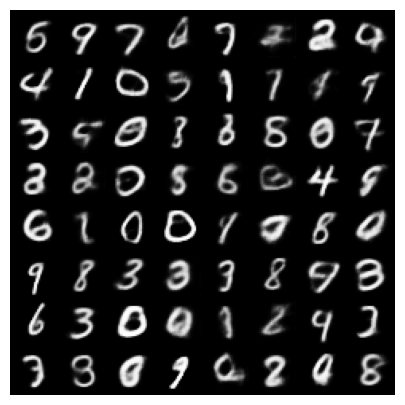

In [15]:
n_epochs = 10
log = Report(n_epochs)
vae = VAE()
optimizer = optim.AdamW(vae.parameters(), lr=0.001)

# loop de treino segue basicamente a mesma logica das outras aulas

for epoch in range(n_epochs):
    N = len(train_loader)
    for batch_idx, (data, _) in enumerate(train_loader):
        loss, recon, kld, log_var, mean = train_batch(data, vae, optimizer, loss_function)
        pos = epoch + (1+batch_idx)/N
        log.record(pos, train_loss=loss, train_kld=kld, train_recon=recon, train_log_var=log_var, train_mean=mean, end='\r')

    N = len(test_loader)
    for batch_idx, (data, _) in enumerate(test_loader):
        loss, recon, kld, log_var, mean = validate_batch(data, vae, loss_function)
        pos = epoch + (1+batch_idx)/N
        log.record(pos, val_loss=loss, val_kld=kld, val_recon=recon, val_log_var=log_var, val_mean=mean, end='\r')

    log.report_avgs(epoch+1)
    with torch.no_grad():
        z = torch.randn(64, 20) # sorteia 64 vetores com 20 ddimensoes
        sample = vae.decode(z) # coloca esses vetores ao decode assim gerando 64 imagens novas(data argumentation)
        images = make_grid(sample.view(64, 1, 28, 28)).permute(1,2,0)
        show(images)